# TP Groupe : Sentiment Analysis sur Amazon Reviews

**Équipe:** PLA Damien, IKHADRIOUENE Farid, DEMAGNY Charles-Henri, KESSALI Myriam 

**Livrables:** Notebook complet + Rapport d'analyse

## Objectif

Construire un système de classification de sentiments sur un corpus réel d'avis Amazon. Le projet intègre toutes les étapes du pipeline NLP : exploration, nettoyage, feature engineering, modélisation multi-modèles, validation et analyse approfondie des performances.

## Phase 1 : Exploration & Analyse

Comprendre la structure réelle des données Amazon.

1. Charger le dataset
   - Parser le format .ft.txt
   - Extraire labels et textes
   - Vérifier intégrité

In [2]:
from scripts.exploration_analyse import (
    load_amazon_ft_file,
    add_text_features,
    build_balanced_subset,
    get_top_n
)
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


file_path = "data/raw/train.ft.txt"
df = load_amazon_ft_file(file_path)
df.head()

,review_id,raw_label,sentiment,review_text
0,0,__label__2,1,Stuning even for the non-gamer: This sound tra...
1,1,__label__2,1,The best soundtrack ever to anything.: I'm rea...
2,2,__label__2,1,Amazing!: This soundtrack is my favorite music...
3,3,__label__2,1,Excellent Soundtrack: I truly like this soundt...
4,4,__label__2,1,"Remember, Pull Your Jaw Off The Floor After He..."


In [3]:
# Vérifier intégrité
print(df.shape)
print(df.isnull().sum())
print(df["raw_label"].value_counts())
print(df["sentiment"].value_counts())

(3600000, 4)
review_id      0
raw_label      0
sentiment      0
review_text    0
dtype: int64
raw_label
__label__2    1800000
__label__1    1800000
Name: count, dtype: int64
sentiment
1    1800000
0    1800000
Name: count, dtype: int64


In [4]:

df_subset = build_balanced_subset(df, n_per_class=3000)
print(df_subset["sentiment"].value_counts())

sentiment
1    3000
0    3000
Name: count, dtype: int64


2. Statistiques descriptives
   - Nombre d'avis par classe
   - Longueur moyenne, min, max
   - Distribution des longueurs
   - Vocabulaire total unique

In [5]:
df_subset = add_text_features(df_subset)
df_subset.head()

,review_id,raw_label,sentiment,review_text,char_len,word_len,has_url,has_html,has_email,special_char_ratio
0,2512340,__label__2,1,Conscious Finance: As a counselor that has wor...,753,121,False,False,False,0.018592
1,2867205,__label__1,0,Poor quality: I just purchased these boots thi...,342,69,False,False,False,0.017544
2,2935598,__label__2,1,Easy learning: This is the greatest book. I pu...,313,60,False,False,False,0.019169
3,3206468,__label__2,1,Heater: I purchased this heater for a sun room...,230,43,False,False,False,0.021739
4,1022113,__label__1,0,Mariah is a cash cow. GET OVER THAT.: Mariah h...,520,92,False,False,False,0.051923


In [6]:
# Statistiques descriptives
stats = df_subset.groupby("sentiment")[["char_len", "word_len"]].agg(["mean", "median", "min", "max"])
stats

print("Nombre total d'avis :", len(df_subset))


Nombre total d'avis : 6000


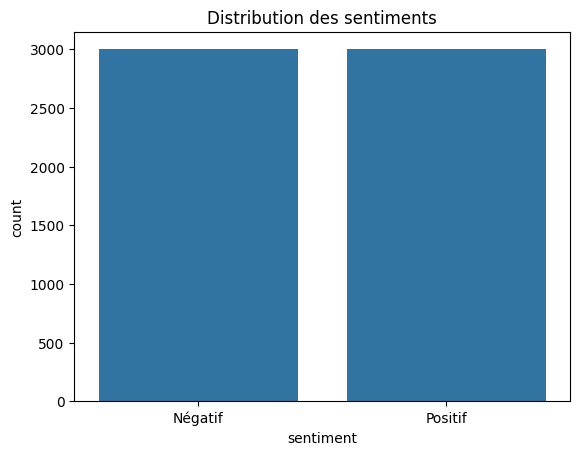

In [7]:
# Distribution des classes
sns.countplot(data=df_subset, x="sentiment")
plt.xticks([0, 1], ["Négatif", "Positif"])
plt.title("Distribution des sentiments")
plt.show()

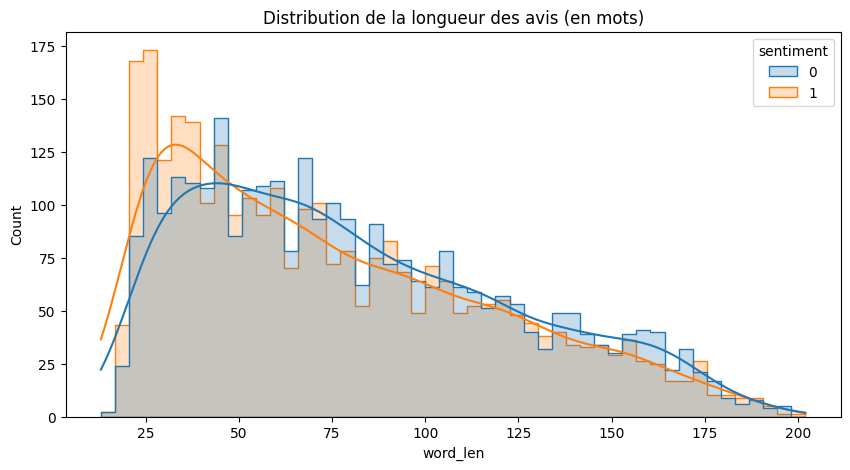

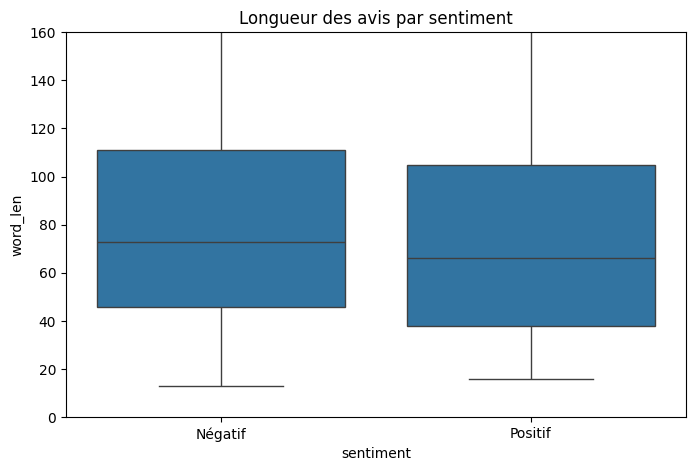

In [10]:
# Distribution des longueurs
plt.figure(figsize=(10, 5))
sns.histplot(data=df_subset, x="word_len", hue="sentiment", bins=50, kde=True, element="step")
plt.title("Distribution de la longueur des avis (en mots)")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_subset, x="sentiment", y="word_len")
plt.xticks([0, 1], ["Négatif", "Positif"])
plt.title("Longueur des avis par sentiment")
plt.ylim(0, df_subset["word_len"].quantile(0.95))
plt.show()

In [11]:
print("Vocabulaire total unique :", len(set(" ".join(df_subset["review_text"]).lower().split())))

Vocabulaire total unique : 51407


3. Analyse textuelle
   - Top 50 mots positifs et négatifs
   - Bigrammes et trigrammes intéressants
   - URLs, emails, mentions
   - Caractères spéciaux communs

In [12]:
# Positifs :

top_words_pos = get_top_n(df_subset[df_subset["sentiment"] == 1]["review_text"], (1,1), 30)
top_words_pos

# Négatifs :

top_words_neg = get_top_n(df_subset[df_subset["sentiment"] == 0]["review_text"], (1,1), 30)
top_words_neg

,term,freq
0,book,1609
1,like,901
2,just,871
3,good,759
4,don,695
5,time,615
6,movie,532
7,read,526
8,really,480
9,product,477


In [18]:
top_bigrams_pos = get_top_n(df_subset[df_subset["sentiment"] == 1]["review_text"], (2,2), 20)
print(top_bigrams_pos)
top_bigrams_neg = get_top_n(df_subset[df_subset["sentiment"] == 0]["review_text"], (2,2), 20)
print(top_bigrams_neg)

                  term  freq
0            read book    99
1           great book    88
2     highly recommend    84
3            book read    64
4             year old    58
5            years ago    58
6        great product    51
7             easy use    41
8          really good    40
9       recommend book    39
10           good book    37
11           long time    37
12        reading book    36
13         great movie    34
14         works great    34
15           easy read    33
16          book great    32
17         great price    32
18  highly recommended    32
19             ve seen    31
                term  freq
0        waste money   135
1          read book    83
2         waste time    83
3          don waste    81
4            don buy    76
5         save money    66
6           don know    63
7   customer service    50
8           year old    47
9            ve read    45
10        time money    41
11        doesn work    39
12      poor quality    39
13         di

In [19]:
top_trigrams_pos = get_top_n(df_subset[df_subset["sentiment"] == 1]["review_text"], (3,3), 15)
print(top_trigrams_pos)
top_trigrams_neg = get_top_n(df_subset[df_subset["sentiment"] == 0]["review_text"], (3,3), 15)
print(top_trigrams_neg)

                     term  freq
0   highly recommend book    14
1         great book read     9
2          book easy read     8
3         jake roberts vs     8
4             noo noo noo     8
5            did good job     6
6           does good job     6
7          does great job     6
8       year old daughter     6
9            year old son     6
10        book great book     5
11           book ve read     5
12          did great job     5
13      great price great     5
14    great product great     5
                       term  freq
0           don waste money    52
1          waste time money    27
2            don waste time    24
3            good like sort    20
4     like sort stuffpretty    18
5     sort stuffpretty good    18
6     stuffpretty good like    18
7            blah blah blah    12
8              don buy book    10
9              book ve read     8
10             year old son     8
11          save time money     7
12         waste money time     7
13  called c

In [15]:
# URLs, emails, mentions
df_subset[["has_url", "has_html", "has_email"]].mean() * 100

has_url      0.250000
has_html     0.083333
has_email    0.083333
dtype: float64

In [20]:
# Reviews avec au moins un caractère spécial commun
df_subset[
    df_subset["review_text"].str.contains(r"[^a-zA-Z0-9\s]", regex=True)
][["review_text"]].head(10)

,review_text
0,Conscious Finance: As a counselor that has wor...
1,Poor quality: I just purchased these boots thi...
2,Easy learning: This is the greatest book. I pu...
3,Heater: I purchased this heater for a sun room...
4,Mariah is a cash cow. GET OVER THAT.: Mariah h...
5,As advertised: The product is as advertised. I...
6,"Fine Biography: All in all, this is a decent b..."
7,Have your child try it before buying: This was...
8,WORKED GREAT!: YOU HAVE TO BE SEMI-CAREFUL MEA...
9,"wonderful stuff: Mundy,a native of Birr,Co.Off..."


4. Patterns réalistes
   - Sarcasme détectable? (exemples)
   - Avis trop courts (bruit?)
   - Avis trop longs (copier-coller?)
   - Répétitions suspectes

Le sarcasme n'est pas encore détectable à ce stade. 

In [ ]:
#avis trop courts (< à 150)
short_reviews = df_subset[df_subset["char_len"] < 150][["sentiment", "review_text"]]
short_reviews.sample(10, random_state=42)

,sentiment,review_text
5017,1,Great CD: I've listen to it all the time and I...
5121,1,Love it.: I've been using this on a nearly dai...
73,1,Excellent!!!: This was a good buy for all the ...
2118,1,"classic: great movie, has all of the bond stuf..."
906,0,Pretty bad: Low quality sound and it does not ...
3165,1,"Works Flawlessly: Great router, very easy to s..."
5999,1,If you enjoyed the music during the movie...: ...
5671,0,misleading: this cd does not actualy teach you...
1317,1,the leveling wind: His conservative view of cu...
1561,1,matches perfectly: this comes with the white p...


In [22]:
# avis trop longs

long_reviews = df_subset[df_subset["word_len"] > df_subset["word_len"].quantile(0.99)]
long_reviews[["sentiment", "word_len", "review_text"]].head(10)

,sentiment,word_len,review_text
49,1,190,Best scope for my ruger 10/22: This is an awes...
168,0,187,What a pity.: The book starts off wonderfully ...
212,1,192,"best fitness DVD i have, the best: the options..."
387,1,191,Love these little Mini Bread Bakers: 1. These ...
412,0,189,Not a Reputable Company: I was given a copy of...
547,1,182,"purchased new, but line was apparently cut and..."
554,0,195,Don't not waste your money on this Sirius Mode...
660,0,186,"""Never"" heard of it..: I can't say i've ever h..."
706,1,189,When you can't see the forest for the trees . ...
731,1,188,Modern take on an old classic: My family and I...


In [23]:
# Répétitions suspectes (doublons)

duplicate_count = df_subset["review_text"].duplicated().sum()
print("Nombre de doublons exacts :", duplicate_count)

duplicates = df_subset[df_subset["review_text"].duplicated(keep=False)].sort_values("review_text")
duplicates.head(20)

Nombre de doublons exacts : 0


,review_id,raw_label,sentiment,review_text,char_len,word_len,has_url,has_html,has_email,special_char_ratio


5. Visualisations
   - Distribution sentiments (class balance)
   - Longueur par sentiment
   - Word clouds positif/négatif
   - Caractéristiques textuelles

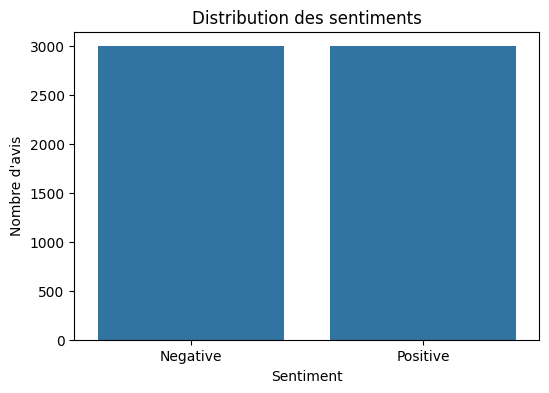

In [24]:
# Distribution des sentiments

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_subset,
    x="sentiment"
)

plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")

plt.show()

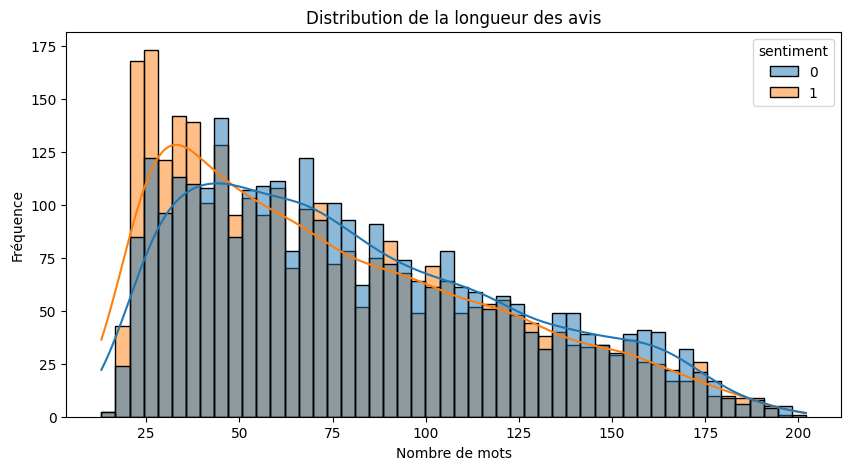

In [25]:
# - Longueur par sentiment

plt.figure(figsize=(10,5))

sns.histplot(
    data=df_subset,
    x="word_len",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")

plt.show()

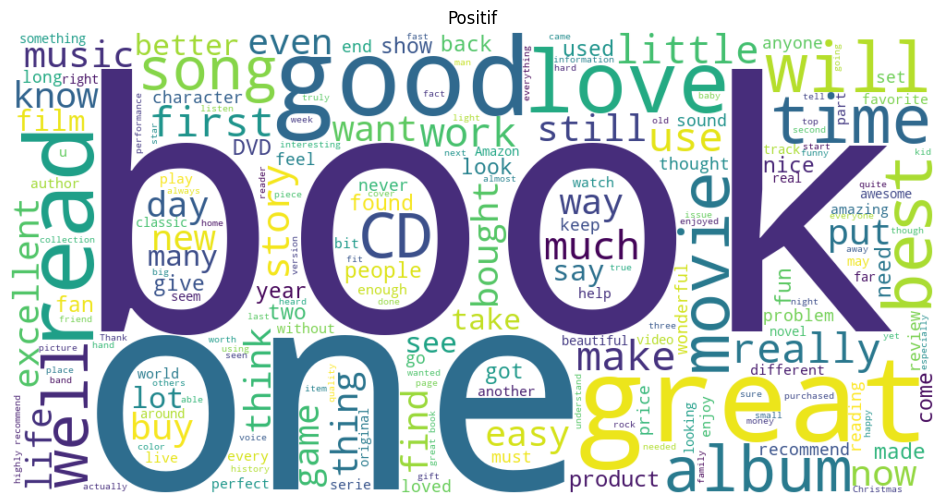

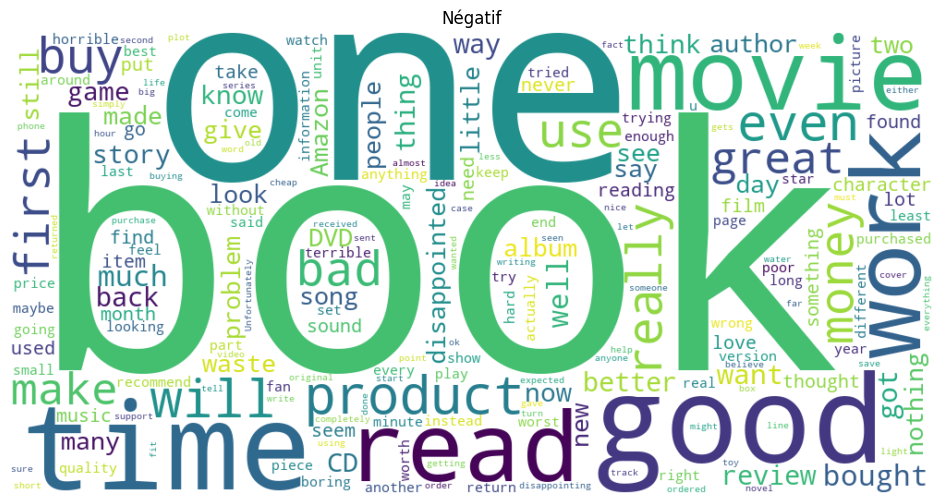

In [26]:
# - Word clouds positif/négatif

from wordcloud import WordCloud

def plot_wordcloud(texts, title):
    text = " ".join(texts)
    wc = WordCloud(width=1000, height=500, background_color="white").generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(df_subset[df_subset["sentiment"] == 1]["review_text"], "Positif")
plot_wordcloud(df_subset[df_subset["sentiment"] == 0]["review_text"], "Négatif")